In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

xgboost_estimators_dict = {
    "XGBoost": estimators_dict["XGBoost"],
    "XGBoost Balanced": estimators_dict["XGBoost Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_xgb, threshold_comparison_xgb, confusion_results_xgb, trained_models_xgb, interpretation_results_xgb = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=xgboost_estimators_dict,
    target=target
)

general_comparison_xgb.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
17,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.5,0.825,0.468,0.620,0.533,0.834,3,8,25
9,Modelo 5 — Estabilidade e Benefícios,XGBoost Balanced,0.5,0.780,0.393,0.676,0.497,0.792,0,9,24
11,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.5,0.787,0.398,0.634,0.489,0.810,0,9,24
3,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.5,0.769,0.378,0.676,0.485,0.793,0,8,22
7,Modelo 4 — Trajetória Organizacional,XGBoost Balanced,0.5,0.780,0.382,0.592,0.464,0.767,0,8,22
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,XGBoost Balanced,0.5,0.810,0.424,0.507,0.462,0.795,3,8,24
1,Modelo 1 — Função Profissional,XGBoost Balanced,0.5,0.766,0.367,0.620,0.461,0.774,0,8,26
29,Modelo 8 — Integrado Multidimensional,XGBoost Balanced,0.5,0.814,0.430,0.479,0.453,0.794,7,11,43
15,Modelo 1 — Função Profissional Misto,XGBoost Balanced,0.5,0.791,0.392,0.535,0.452,0.768,3,7,26
4,Modelo 3 — Faixa Salarial,XGBoost,0.5,0.873,0.742,0.324,0.451,0.786,0,8,21


In [4]:
best_thresholds_xgb = threshold_comparison_xgb.loc[
    threshold_comparison_xgb.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_xgb.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
6,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost,0.300,0.859,0.565,0.549,0.557,0.833
7,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.525,0.837,0.494,0.620,0.550,0.834
5,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.650,0.844,0.513,0.563,0.537,0.793
4,Modelo 2 — Nível Hierárquico,XGBoost,0.300,0.846,0.521,0.521,0.521,0.804
18,Modelo 5 — Estabilidade e Benefícios,XGBoost,0.325,0.857,0.567,0.479,0.519,0.795
8,Modelo 3 — Faixa Salarial,XGBoost,0.250,0.828,0.471,0.577,0.519,0.786
0,Modelo 1 — Função Profissional,XGBoost,0.300,0.846,0.522,0.493,0.507,0.779
19,Modelo 5 — Estabilidade e Benefícios,XGBoost Balanced,0.650,0.846,0.522,0.493,0.507,0.792
9,Modelo 3 — Faixa Salarial,XGBoost Balanced,0.625,0.828,0.470,0.549,0.506,0.786
20,Modelo 6 — Perfil Pessoal,XGBoost,0.200,0.805,0.427,0.620,0.506,0.814


In [5]:
top_5_best_xgb = best_thresholds_xgb.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_xgb

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost,0.300,0.859,0.565,0.549,0.557,0.833
1,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.525,0.837,0.494,0.620,0.550,0.834
2,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.650,0.844,0.513,0.563,0.537,0.793
3,Modelo 2 — Nível Hierárquico,XGBoost,0.300,0.846,0.521,0.521,0.521,0.804
4,Modelo 5 — Estabilidade e Benefícios,XGBoost,0.325,0.857,0.567,0.479,0.519,0.795


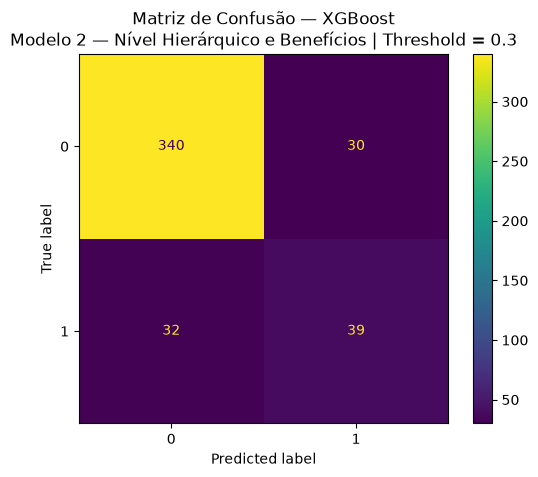

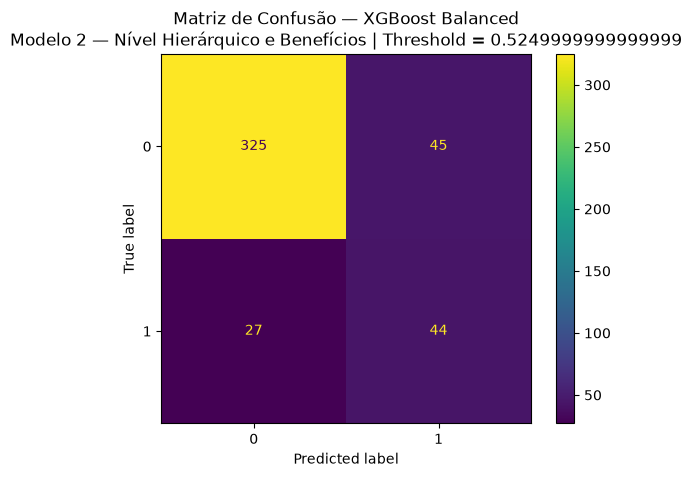

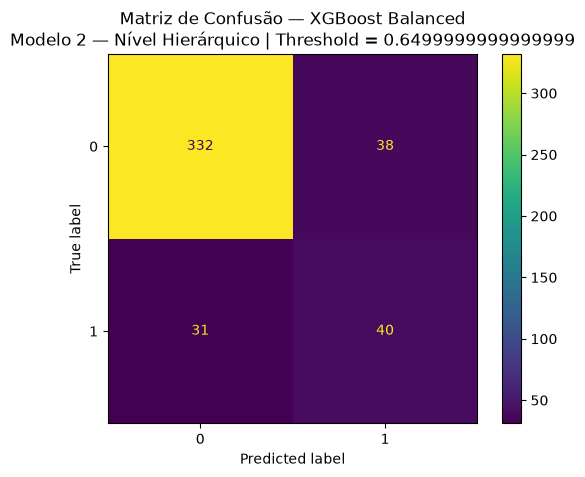

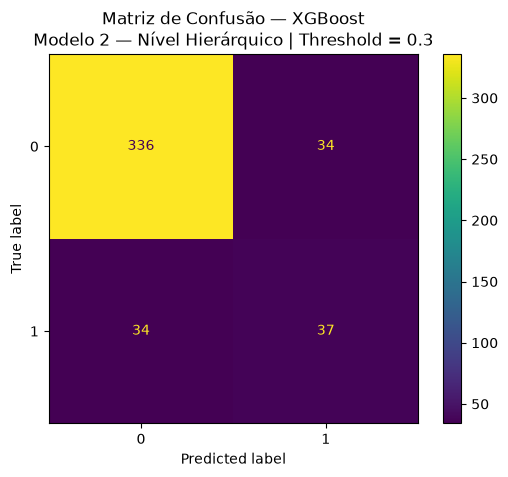

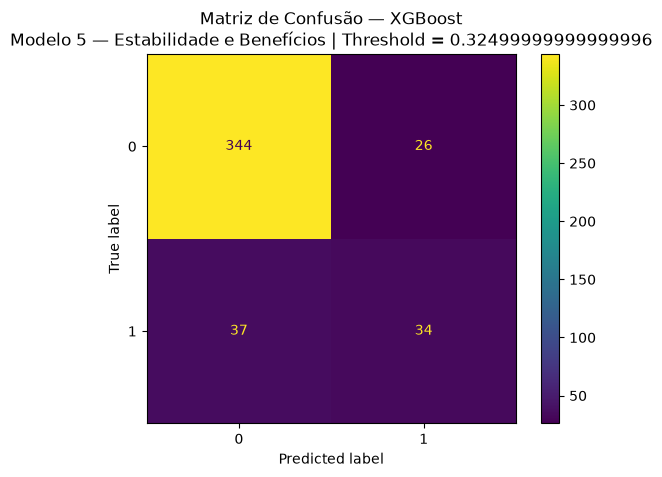

In [6]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(xgboost_estimators_dict[model_name]["estimator"])
    balance_method = xgboost_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

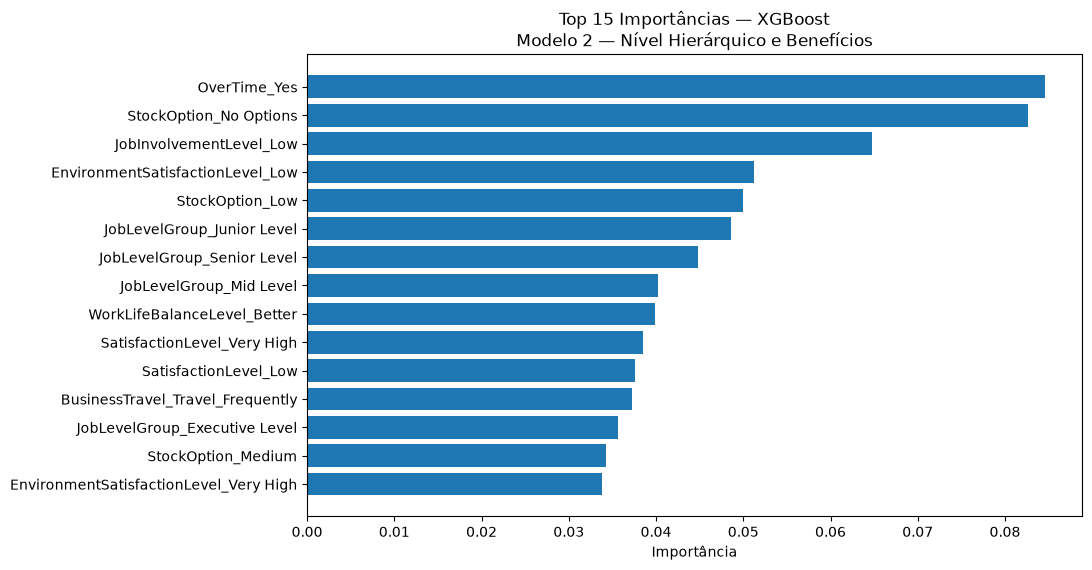

,Feature,Importance
3,OverTime_Yes,0.084607
10,StockOption_No Options,0.082660
13,JobInvolvementLevel_Low,0.064728
16,EnvironmentSatisfactionLevel_Low,0.051252
8,StockOption_Low,0.049993
5,JobLevelGroup_Junior Level,0.048649
7,JobLevelGroup_Senior Level,0.044818
6,JobLevelGroup_Mid Level,0.040203
23,WorkLifeBalanceLevel_Better,0.039880
21,SatisfactionLevel_Very High,0.038487


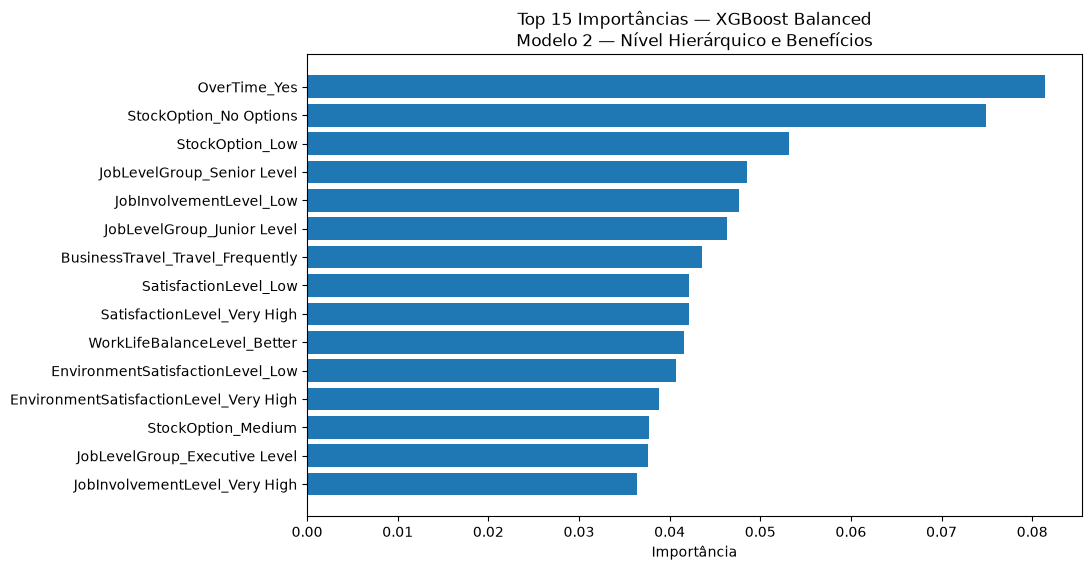

,Feature,Importance
3,OverTime_Yes,0.081431
10,StockOption_No Options,0.074857
8,StockOption_Low,0.053175
7,JobLevelGroup_Senior Level,0.048484
13,JobInvolvementLevel_Low,0.047663
5,JobLevelGroup_Junior Level,0.046336
11,BusinessTravel_Travel_Frequently,0.043585
19,SatisfactionLevel_Low,0.042155
21,SatisfactionLevel_Very High,0.042134
23,WorkLifeBalanceLevel_Better,0.041617


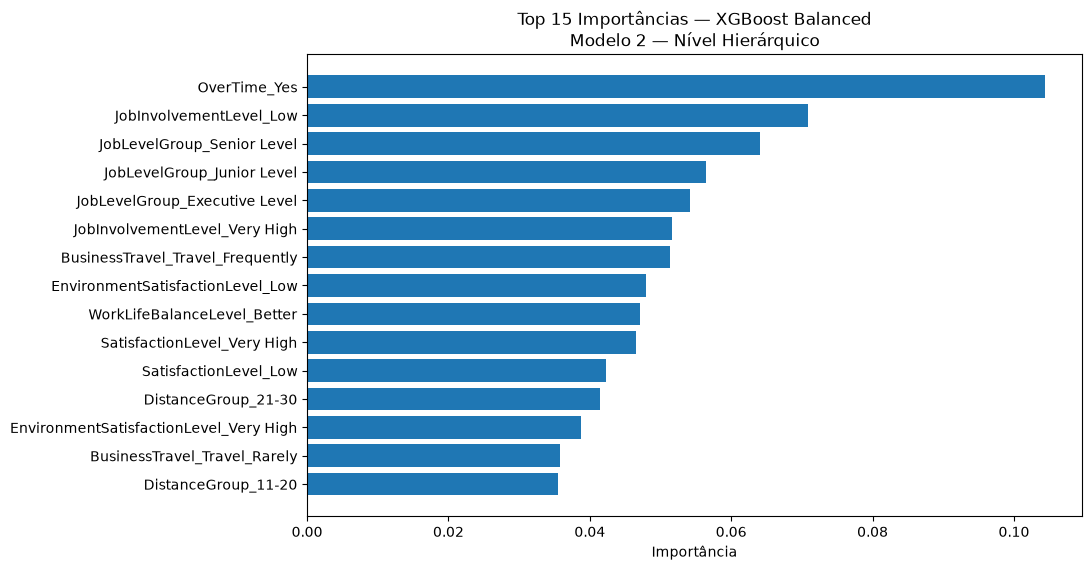

,Feature,Importance
0,OverTime_Yes,0.104416
7,JobInvolvementLevel_Low,0.070900
4,JobLevelGroup_Senior Level,0.064079
2,JobLevelGroup_Junior Level,0.056425
1,JobLevelGroup_Executive Level,0.054171
9,JobInvolvementLevel_Very High,0.051685
5,BusinessTravel_Travel_Frequently,0.051341
10,EnvironmentSatisfactionLevel_Low,0.048008
17,WorkLifeBalanceLevel_Better,0.047070
15,SatisfactionLevel_Very High,0.046596


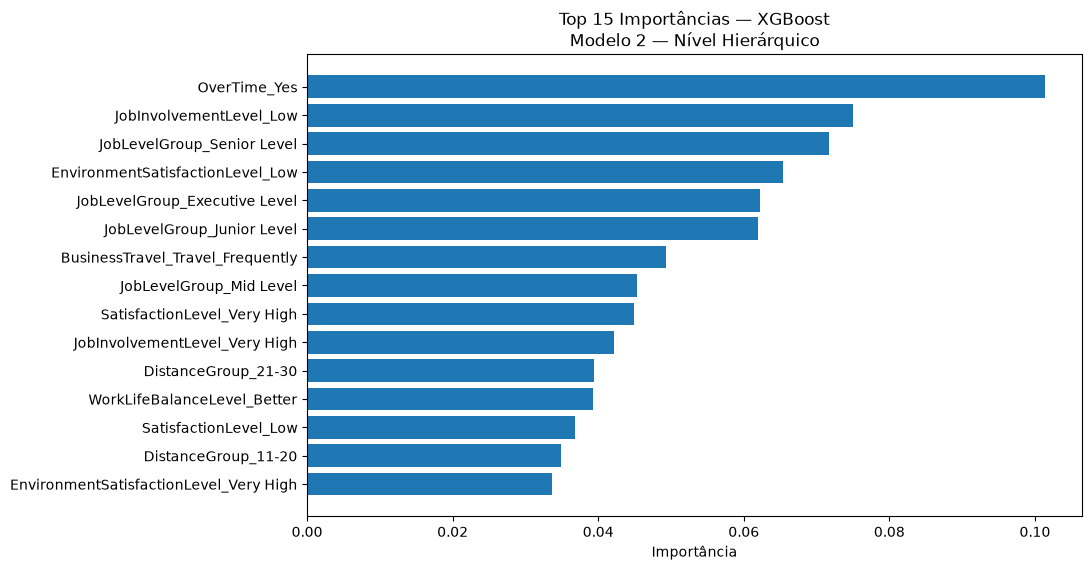

,Feature,Importance
0,OverTime_Yes,0.101407
7,JobInvolvementLevel_Low,0.074968
4,JobLevelGroup_Senior Level,0.071753
10,EnvironmentSatisfactionLevel_Low,0.065444
1,JobLevelGroup_Executive Level,0.062182
2,JobLevelGroup_Junior Level,0.061998
5,BusinessTravel_Travel_Frequently,0.049327
3,JobLevelGroup_Mid Level,0.045327
15,SatisfactionLevel_Very High,0.044949
9,JobInvolvementLevel_Very High,0.042133


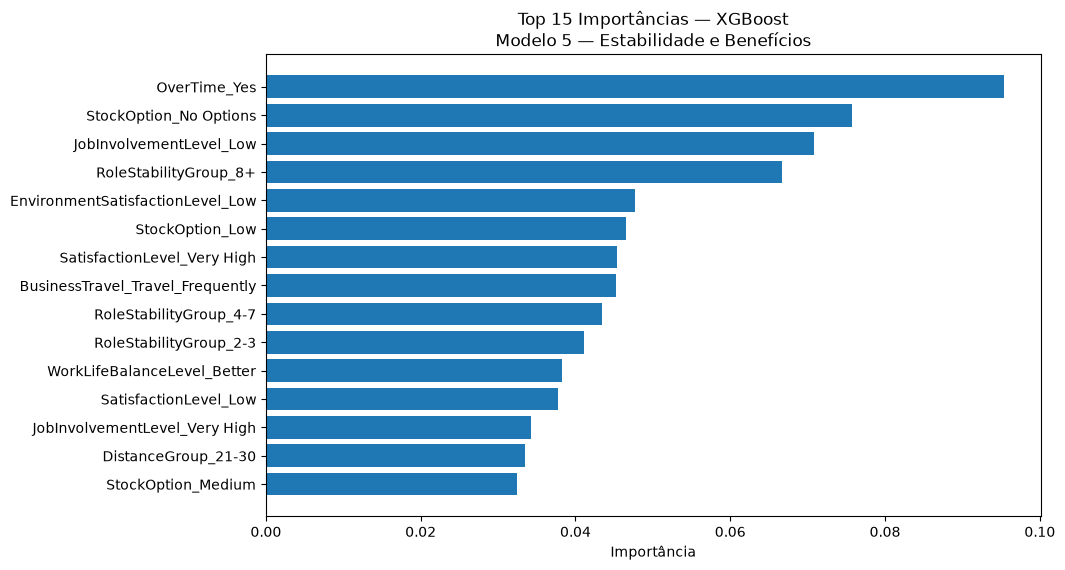

,Feature,Importance
0,OverTime_Yes,0.095371
6,StockOption_No Options,0.075672
9,JobInvolvementLevel_Low,0.070819
3,RoleStabilityGroup_8+,0.066699
12,EnvironmentSatisfactionLevel_Low,0.047668
4,StockOption_Low,0.046562
17,SatisfactionLevel_Very High,0.045348
7,BusinessTravel_Travel_Frequently,0.045216
2,RoleStabilityGroup_4-7,0.043478
1,RoleStabilityGroup_2-3,0.041152


In [7]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_xgb[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — XGBoost | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


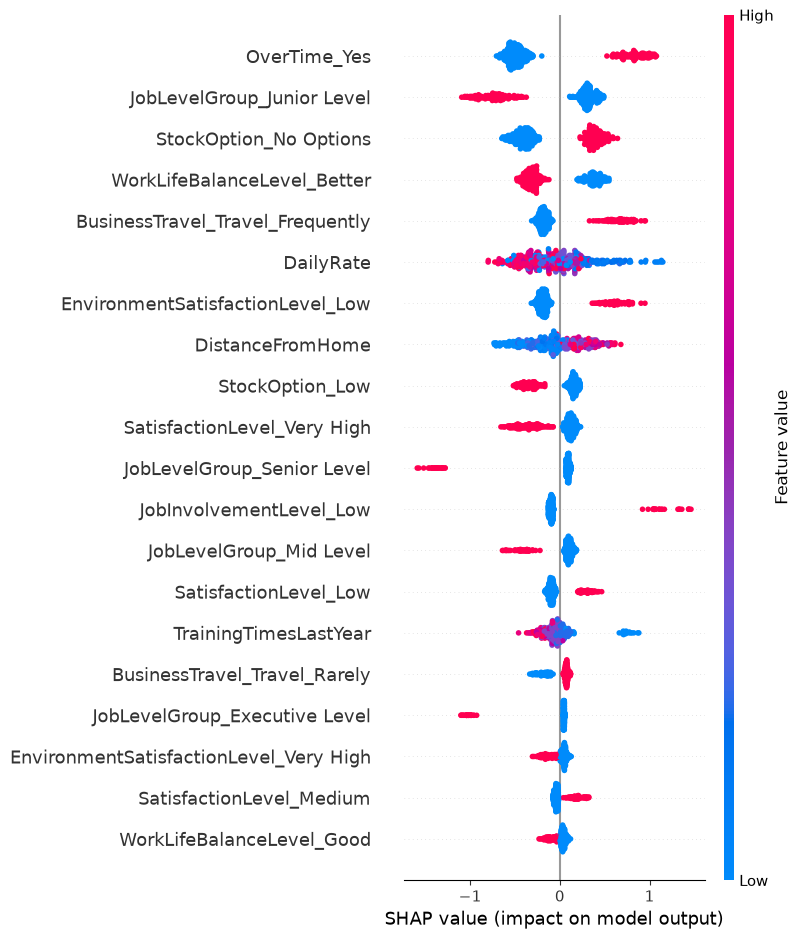

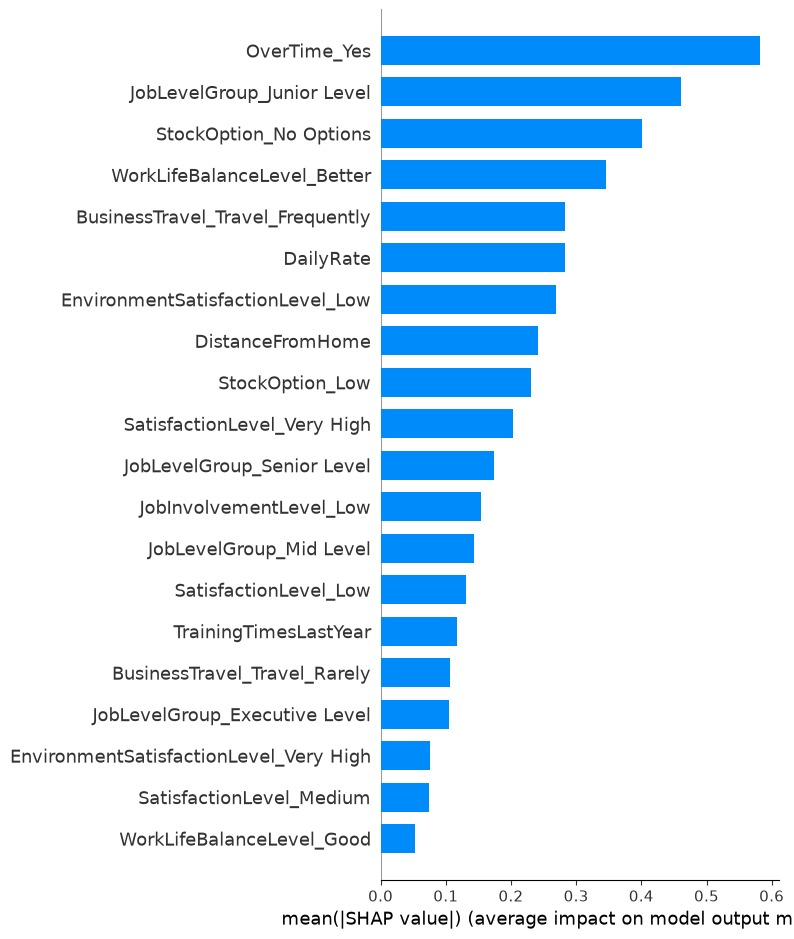

SHAP — XGBoost Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


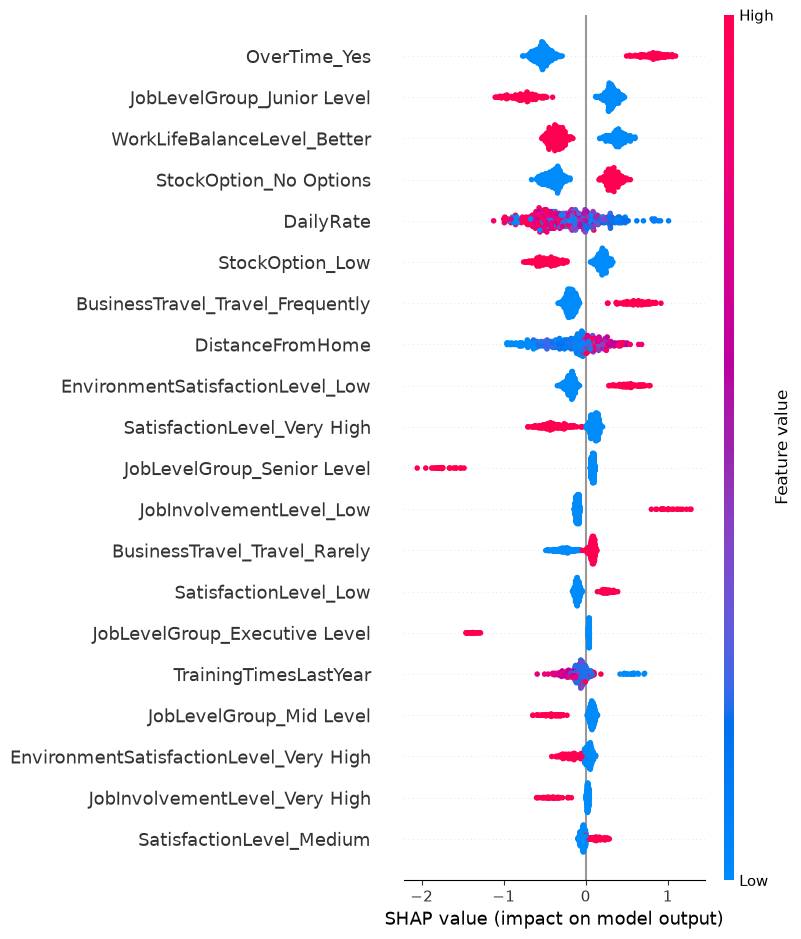

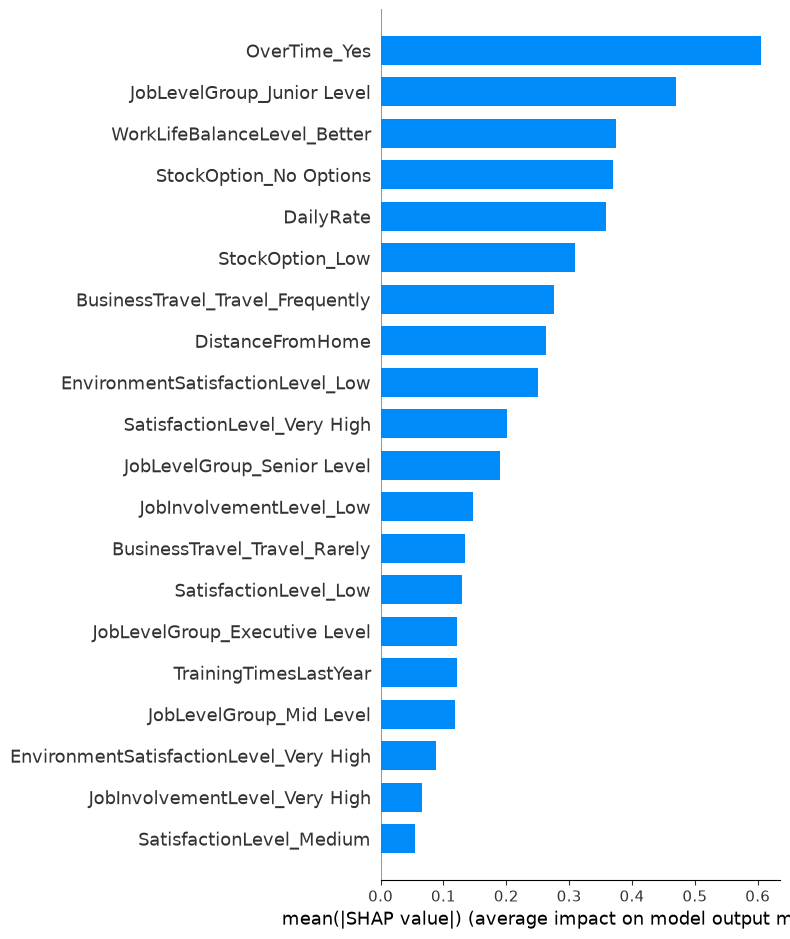

SHAP — XGBoost Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


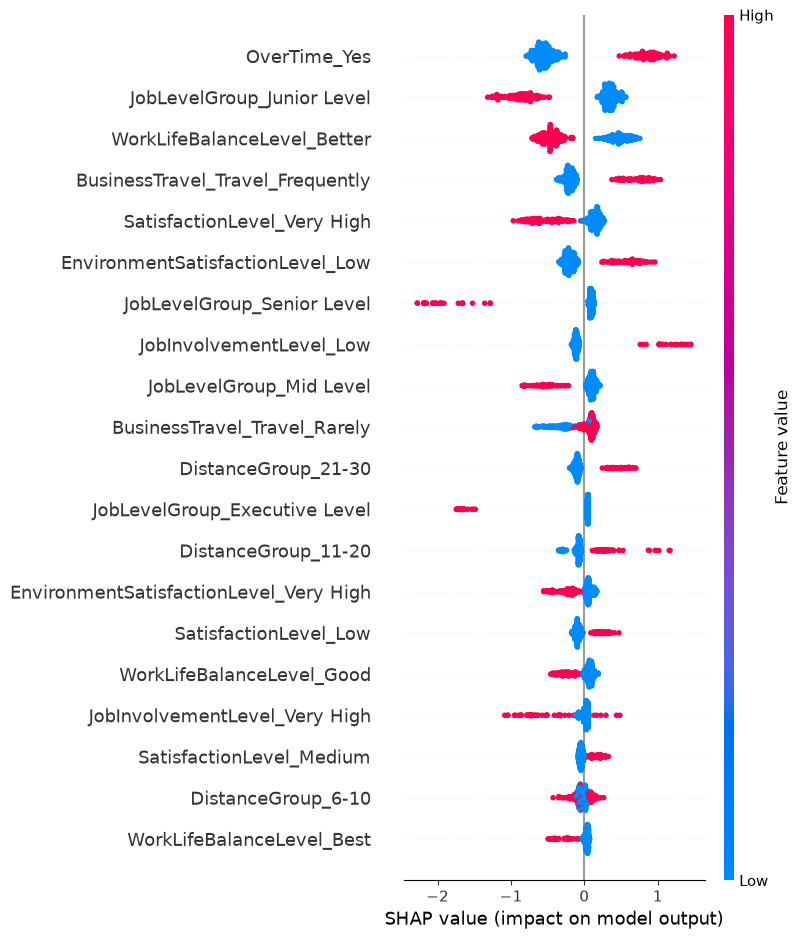

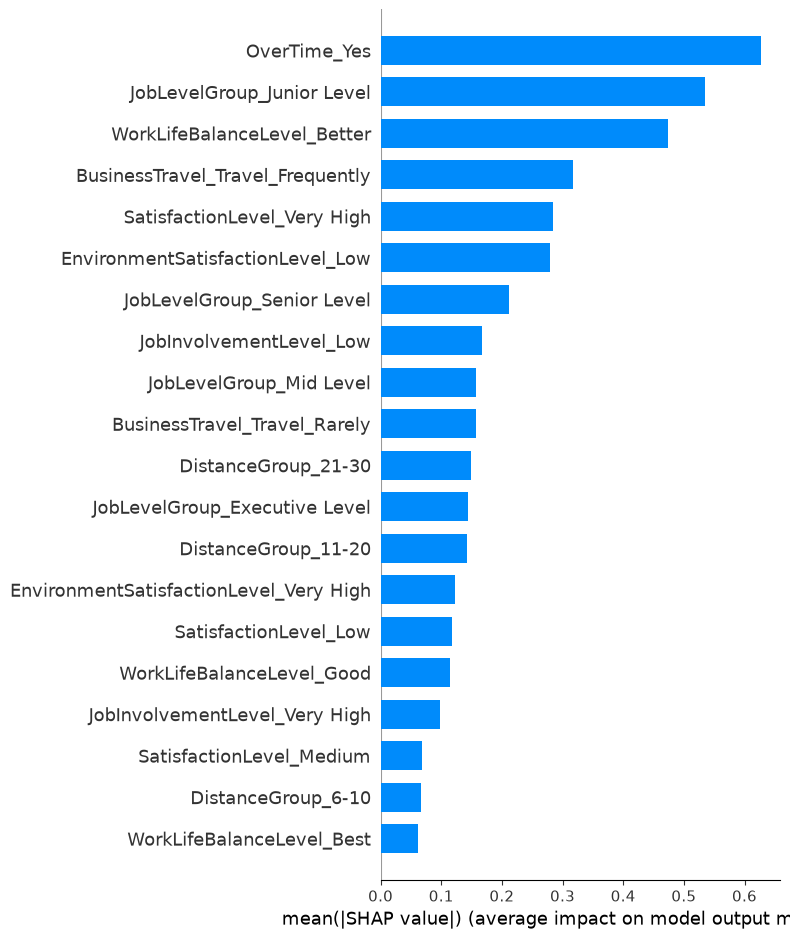

SHAP — XGBoost | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


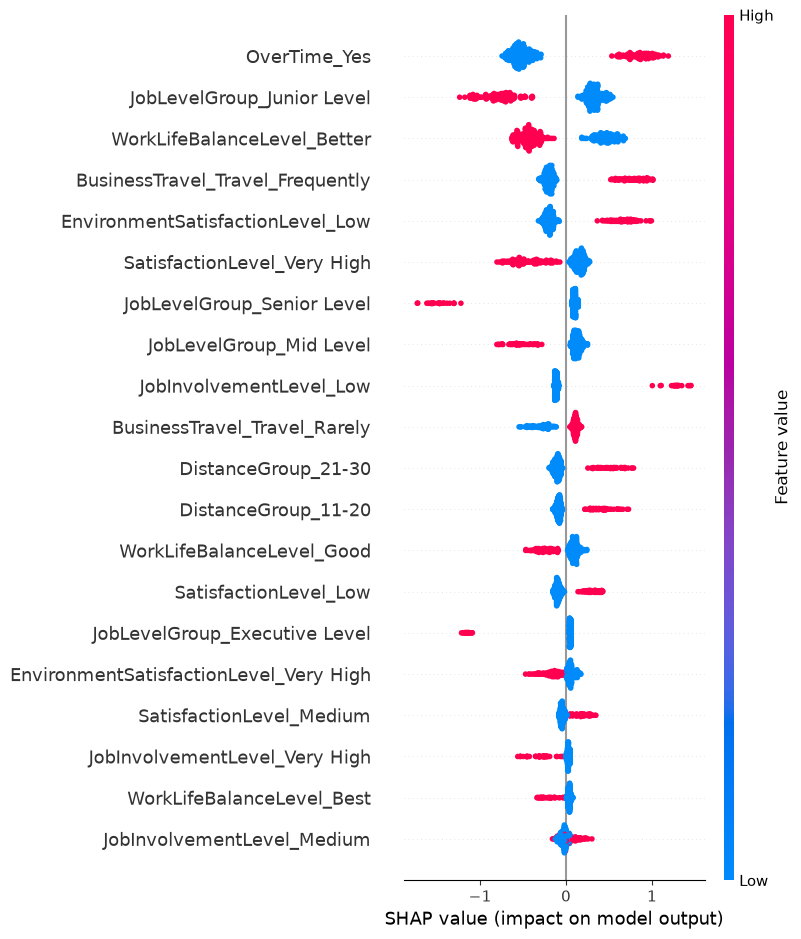

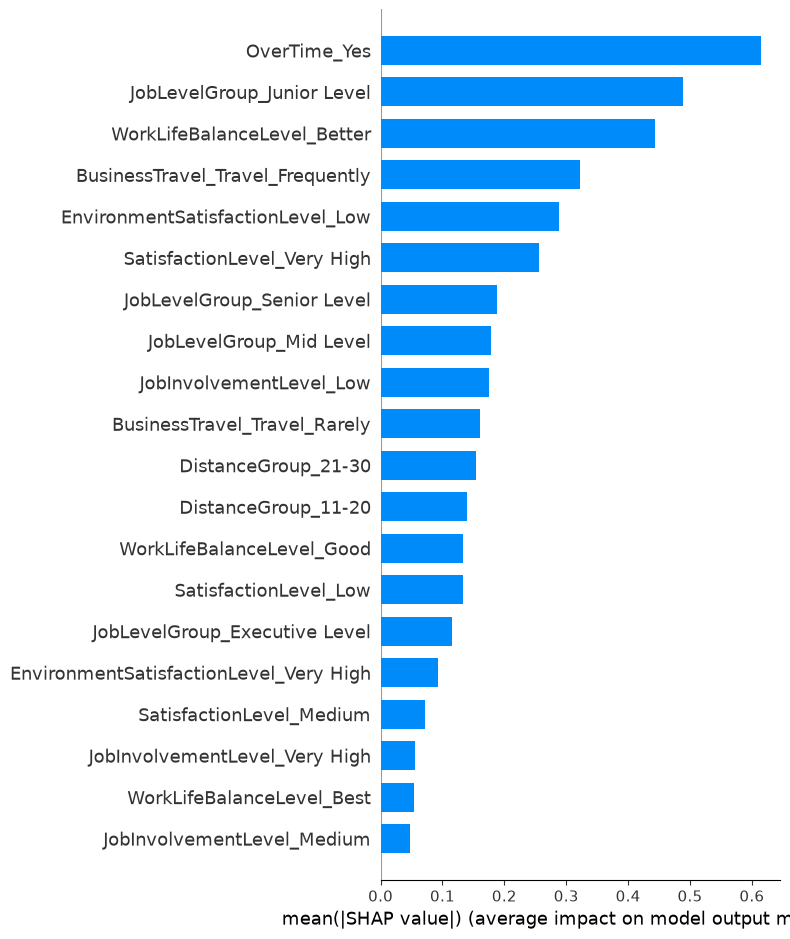

SHAP — XGBoost | Modelo 5 — Estabilidade e Benefícios
(441, 24)
(441, 24)


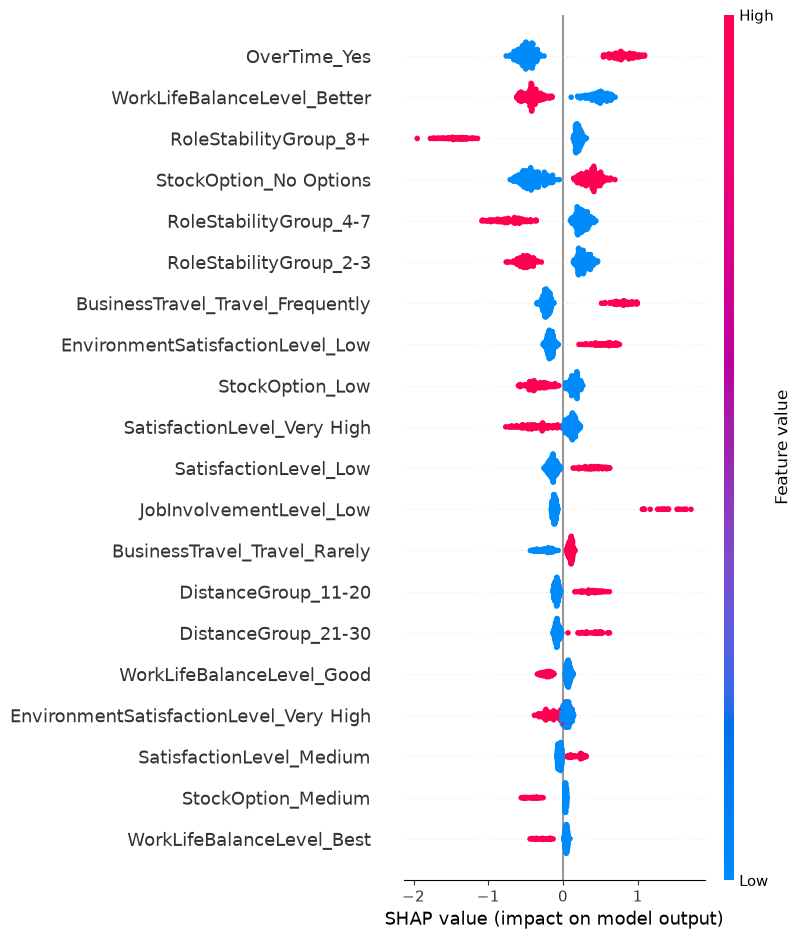

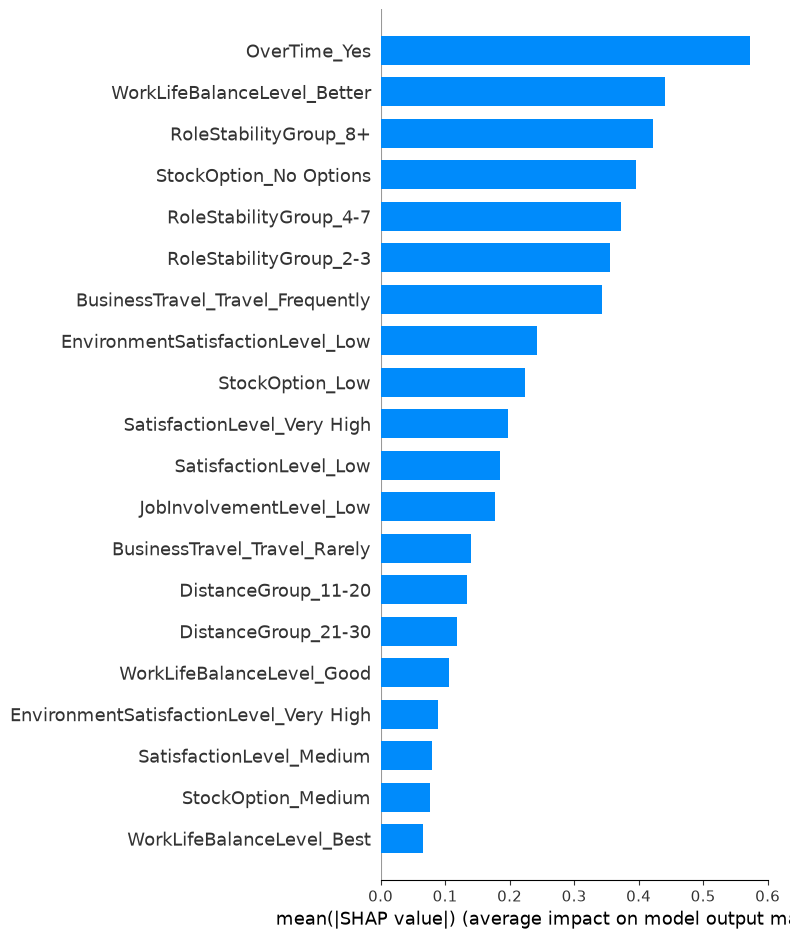

In [8]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(xgboost_estimators_dict[model_name]["estimator"])
    balance_method = xgboost_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_xgb = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "XGBoost": estimators_dict["XGBoost"],
        "XGBoost Balanced": estimators_dict["XGBoost Balanced"]
    },
    target="AttritionFlag"
)

cv_xgb.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,XGBoost Balanced,0.816,0.031,0.448,0.070,0.590,0.087,0.509,0.075,0.811,0.050,7,11,43
7,Modelo 4 — Trajetória Organizacional,XGBoost Balanced,0.763,0.042,0.376,0.059,0.661,0.080,0.476,0.054,0.775,0.044,0,8,22
28,Modelo 8 — Integrado Multidimensional,XGBoost,0.872,0.015,0.707,0.101,0.354,0.056,0.471,0.068,0.817,0.052,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.778,0.027,0.385,0.045,0.607,0.079,0.469,0.049,0.779,0.044,3,8,25
11,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.764,0.025,0.370,0.036,0.645,0.079,0.468,0.040,0.769,0.047,0,9,24
1,Modelo 1 — Função Profissional,XGBoost Balanced,0.755,0.027,0.359,0.036,0.649,0.082,0.460,0.041,0.773,0.038,0,8,26
9,Modelo 5 — Estabilidade e Benefícios,XGBoost Balanced,0.761,0.037,0.367,0.053,0.628,0.074,0.460,0.050,0.782,0.043,0,9,24
15,Modelo 1 — Função Profissional Misto,XGBoost Balanced,0.763,0.026,0.362,0.040,0.607,0.085,0.452,0.049,0.765,0.043,3,7,26
5,Modelo 3 — Faixa Salarial,XGBoost Balanced,0.757,0.026,0.356,0.039,0.619,0.089,0.451,0.048,0.761,0.061,0,8,21
19,Modelo 3 — Rendimento Quantitativo,XGBoost Balanced,0.776,0.030,0.374,0.047,0.557,0.045,0.447,0.046,0.767,0.041,4,6,19
